<img src="../Decorative-Elements/Section-03/Section-03-04/Section-03-04-05.png">
<p style="display: flex; justify-content: space-between;">
  <a href="../03-Solar-System/04-Moon-Orbits-of-Each-Planet-04.ipynb" target="_blank">Previous</a>
  <a href="../03-Solar-System/04-Moon-Orbits-of-Each-Planet-06.ipynb" target="_blank">Next</a>
</p>

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import plotly.graph_objects as go

In [2]:
# Planet: Jupiter

# Average distance from Sun: 5.2 AU
# Orbital period around Sun: 11.86 Earth years
# Orbital period in days: 4333 days
# Total number of confirmed moons: 95+

# 11.86 Earth years is equivalent to approximately 4333 days.
# Jupiter takes much longer than Earth to complete one revolution around the Sun.

# Rotation period (one spin on its axis): 9.9 hours
# Jupiter has the shortest rotation period among all planets.
# It rotates very rapidly compared to its long orbital period.

# Major Moons (Galilean Moons):

# Io
# Orbital period: 1.77 days

# Europa
# Orbital period: 3.55 days

# Ganymede
# Orbital period: 7.15 days
# Largest moon in the Solar System

# Callisto
# Orbital period: 16.69 days

# Io revolves fastest among the Galilean moons.
# Callisto has the longest orbital period among the four major moons.

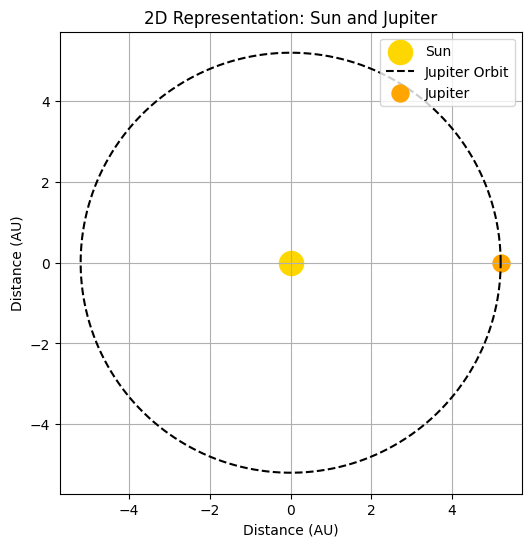

In [3]:
jupiter_radius = 5.2  # AU

theta = np.linspace(0, 2*np.pi, 400)

x_orbit = jupiter_radius * np.cos(theta)
y_orbit = jupiter_radius * np.sin(theta)

plt.figure(figsize=(6,6))

# Sun
plt.scatter(0, 0, s=300, color='gold', label='Sun')

# Jupiter orbit
plt.plot(x_orbit, y_orbit, linestyle='--', color='black', label='Jupiter Orbit')

# Jupiter position
plt.scatter(jupiter_radius, 0, s=150, color='orange', label='Jupiter')

plt.gca().set_aspect('equal', 'box')
plt.title("2D Representation: Sun and Jupiter")
plt.xlabel("Distance (AU)")
plt.ylabel("Distance (AU)")
plt.legend(loc='upper right')
plt.grid(True)

plt.show()

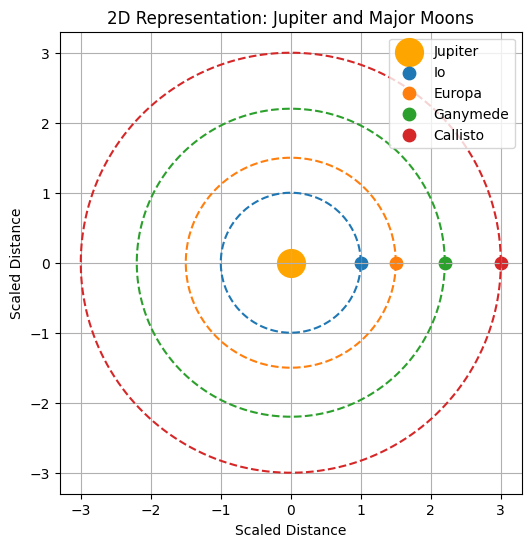

In [4]:
# Orbital radii scaled (not AU)
moon_radii = {
    "Io": 1.0,
    "Europa": 1.5,
    "Ganymede": 2.2,
    "Callisto": 3.0
}

theta = np.linspace(0, 2*np.pi, 400)

plt.figure(figsize=(6,6))

# Jupiter at center
plt.scatter(0, 0, s=400, color='orange', label='Jupiter')

# Draw moon orbits and positions
for moon, radius in moon_radii.items():
    x_orbit = radius * np.cos(theta)
    y_orbit = radius * np.sin(theta)
    
    plt.plot(x_orbit, y_orbit, linestyle='--')
    plt.scatter(radius, 0, s=80, label=moon)

plt.gca().set_aspect('equal', 'box')
plt.title("2D Representation: Jupiter and Major Moons")
plt.xlabel("Scaled Distance")
plt.ylabel("Scaled Distance")
plt.legend(loc='upper right')
plt.grid(True)

plt.show()

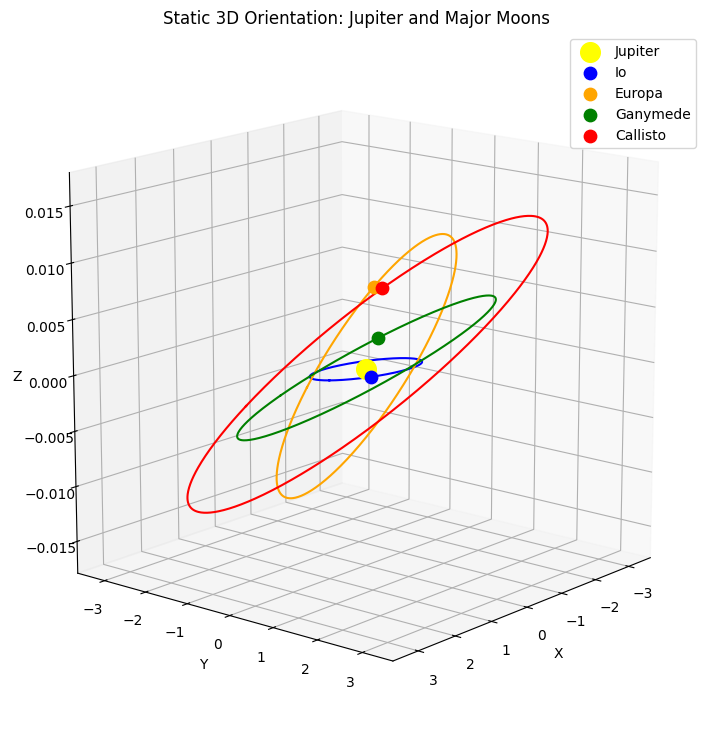

In [5]:
moon_data = {
    "Io": (1.0, 0.05, "blue"),
    "Europa": (1.6, 0.47, "orange"),
    "Ganymede": (2.3, 0.20, "green"),
    "Callisto": (3.2, 0.28, "red")
}

theta = np.linspace(0, 2*np.pi, 600)

fig = plt.figure(figsize=(9,9))
ax = fig.add_subplot(111, projection='3d')

# Jupiter
ax.scatter(0, 0, 0, s=200, color='yellow', label='Jupiter')

for moon, (radius, inc_deg, color) in moon_data.items():

    inc = np.radians(inc_deg)

    # Base orbit
    x = radius * np.cos(theta)
    y = radius * np.sin(theta)
    z = np.zeros_like(theta)

    # Incline orbit about x-axis
    y_rot = y * np.cos(inc)
    z_rot = y * np.sin(inc)

    ax.plot(x, y_rot, z_rot, color=color)

    # Moon position at theta = 45° (so tilt is visible)
    angle = np.pi / 4
    moon_x = radius * np.cos(angle)
    moon_y = radius * np.sin(angle) * np.cos(inc)
    moon_z = radius * np.sin(angle) * np.sin(inc)

    ax.scatter(moon_x, moon_y, moon_z, s=80, color=color, label=moon)

ax.set_title("Static 3D Orientation: Jupiter and Major Moons")
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")

ax.set_box_aspect([1,1,1])

# Slight elevation so inclination is visible but realistic
ax.view_init(elev=15, azim=40)

ax.legend(loc="upper right")

plt.show()

In [6]:
# Moon data: (scaled radius, actual inclination in degrees, color)
moon_data = {
    "Io": (1.0, 0.05, "blue"),
    "Europa": (1.6, 0.47, "orange"),
    "Ganymede": (2.3, 0.20, "green"),
    "Callisto": (3.2, 0.28, "red")
}

theta = np.linspace(0, 2*np.pi, 600)

fig = go.Figure()

# Jupiter at origin
fig.add_trace(go.Scatter3d(
    x=[0], y=[0], z=[0],
    mode='markers',
    marker=dict(size=20, color='yellow'),
    name='Jupiter'
))

for moon, (radius, inc_deg, color) in moon_data.items():
    
    # Convert inclination to radians
    inc = np.radians(inc_deg)
    
    # Base circular orbit in xy-plane
    x = radius * np.cos(theta)
    y_base = radius * np.sin(theta)
    z_base = np.zeros_like(theta)
    
    # Inclination (rotate about x-axis)
    y_rot = y_base * np.cos(inc)
    z_rot = y_base * np.sin(inc)
    
    # Orbit line
    fig.add_trace(go.Scatter3d(
        x=x, y=y_rot, z=z_rot,
        mode='lines',
        line=dict(color=color, width=2),
        name=f'{moon} Orbit'
    ))
    
    # Moon position at 45° along orbit
    angle = np.pi / 4
    moon_x = radius * np.cos(angle)
    moon_y = radius * np.sin(angle) * np.cos(inc)
    moon_z = radius * np.sin(angle) * np.sin(inc)
    
    fig.add_trace(go.Scatter3d(
        x=[moon_x], y=[moon_y], z=[moon_z],
        mode='markers',
        marker=dict(size=6, color=color),
        name=moon
    ))

# Layout
fig.update_layout(
    title="Static 3D Orientation: Jupiter and Galilean Moons",
    scene=dict(
        xaxis_title='X',
        yaxis_title='Y',
        zaxis_title='Z',
        aspectmode='data'
    ),
    width=900,
    height=900,
    showlegend=True
)

fig.show()

# Output is not visible in github webpage, refer to Folder/Output-Plotly

<p style="display: flex; justify-content: space-between;">
  <a href="../03-Solar-System/04-Moon-Orbits-of-Each-Planet-04.ipynb" target="_blank">Previous</a>
  <a href="../03-Solar-System/04-Moon-Orbits-of-Each-Planet-06.ipynb" target="_blank">Next</a>
</p>

<img src="../Decorative-Elements/Section-Footer-Animated/Section-03-04/Section-03-04-e.gif">